In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pingouin as pg
palette = {
    "ME_leg": "#7b8895",
    "gamma1": "#E76F51",
    "gamma2": "#EFAE22",
    "gamma3": "#DCCF67",
    "gamma4": "#95BE56",
    "gamma5": "#4FA9D9",
    "betap2": "#A566A8",
}

In [2]:
all = pd.read_feather('./motion_calcium_analysis_synced.feather')
all

,index,E-phys,Mean(gamma1),Mean(gamma2ap),Mean(gamma3),Mean(gamma4),Mean(gamma5),Mean(betap2),Opto,Time,ME_legs,Opto_ME,Time_ME,Recording,ME_leg_onset,Mean(brtap1),Mean(gamma2)
0,0,-0.136239,-0.395848,-0.165662,0.120374,0.135415,-0.501094,0.646156,0,0.000,-0.537116,0.0,0.005164,29.06.23_A48_exp,0,NaN,NaN
1,1,-0.136239,-0.309367,-0.085300,0.055144,-0.114857,0.003890,0.866254,0,0.025,-0.558516,0.0,0.025819,29.06.23_A48_exp,0,NaN,NaN
2,2,-0.136954,-0.275408,-0.090052,0.029576,-0.325957,0.048142,1.038529,0,0.050,-0.561375,0.0,0.051638,29.06.23_A48_exp,0,NaN,NaN
3,3,-0.137669,-0.102286,-0.073133,0.051311,-0.496768,-0.144420,1.109208,0,0.075,-0.518880,0.0,0.074875,29.06.23_A48_exp,0,NaN,NaN
4,4,-0.138384,0.141175,-0.183011,-0.188045,-0.511550,-0.175254,0.747470,0,0.100,-0.536168,0.0,0.098113,29.06.23_A48_exp,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26050,2395,0.000000,0.626713,0.090898,-0.144554,0.064128,-0.361005,0.742675,0,59.875,0.000000,0.0,59.905621,20231229_A74_pre+motion,0,NaN,NaN
26051,2396,0.000000,0.023156,-0.179581,-0.478330,0.033504,-0.355439,-0.467964,0,59.900,0.000000,0.0,59.930789,20231229_A74_pre+motion,0,NaN,NaN
26052,2397,0.000000,-0.207822,-0.269063,-0.243035,-0.153417,-0.459372,-0.161767,0,59.925,0.000000,0.0,59.955956,20231229_A74_pre+motion,0,NaN,NaN
26053,2398,0.000000,0.094316,-0.412545,-0.587842,0.545884,-0.118706,-0.680473,0,59.950,0.000000,0.0,59.981124,20231229_A74_pre+motion,0,NaN,NaN


# Ext Data Fig 8e

In [3]:
pg.corr(all['Mean(gamma1)'], all['ME_legs'])

,n,r,CI95%,p-val,BF10,power
pearson,25574,0.339188,"[0.33, 0.35]",0.0,inf,1.0


In [4]:
pg.corr(all['Mean(gamma2ap)'], all['ME_legs'])

,n,r,CI95%,p-val,BF10,power
pearson,23214,0.415252,"[0.4, 0.43]",0.0,inf,1.0


In [5]:
pg.corr(all['Mean(gamma3)'], all['ME_legs'])

,n,r,CI95%,p-val,BF10,power
pearson,25574,0.434989,"[0.42, 0.44]",0.0,inf,1.0


In [6]:
pg.corr(all['Mean(gamma4)'], all['ME_legs'])

,n,r,CI95%,p-val,BF10,power
pearson,25574,0.133131,"[0.12, 0.15]",1.866937e-101,1.542e+97,1.0


In [7]:
pg.corr(all['Mean(gamma5)'], all['ME_legs'])

,n,r,CI95%,p-val,BF10,power
pearson,25574,0.080107,"[0.07, 0.09]",1.105427e-37,4.361e+33,1.0


In [8]:
pg.corr(all['Mean(betap2)'], all['ME_legs'])

,n,r,CI95%,p-val,BF10,power
pearson,25574,0.069735,"[0.06, 0.08]",6.053639e-29,9.146e+24,1.0


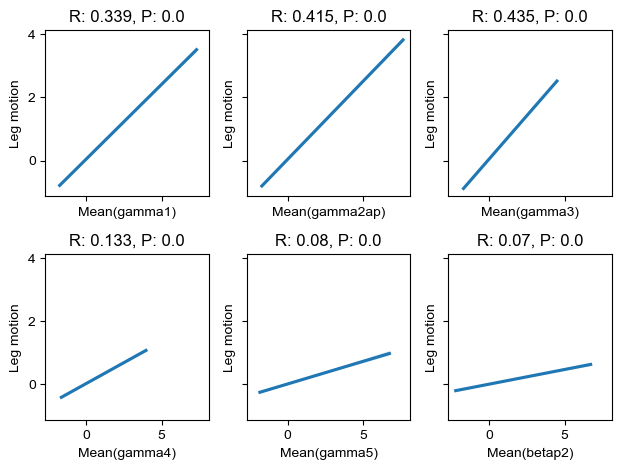

In [9]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True)

for ax, colname in zip(axs.flatten(), all.columns[2:8]):
    line_legs = sns.regplot(data=all, x=colname, y='ME_legs', ci=68, ax=ax, scatter=0)
    ax.set_ylabel('Leg motion')
    ax.set_xlabel(colname)
    ax.set_title(f'R: {pg.corr(all[colname], all['ME_legs'])['r'].values[0].round(3)}, P: {pg.corr(all[colname], all['ME_legs'])['p-val'].values[0].round(3)}')

fig.tight_layout()


# Ext Data Fig 8f

Text(0.5, 1.0, "Pearson's correlation")

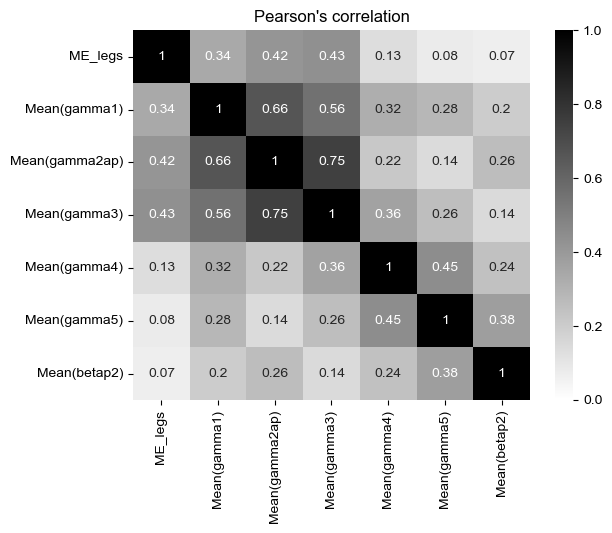

In [10]:
sns.heatmap(all[['ME_legs', 'Mean(gamma1)', 'Mean(gamma2ap)', 'Mean(gamma3)',
       'Mean(gamma4)', 'Mean(gamma5)', 'Mean(betap2)' 
       ]].corr(), cmap='gray_r', vmin=0, vmax=1, annot=True).set_title("Pearson's correlation")


# Ext Data Fig 8b

In [11]:
all['Time_ds2'] = (all.Time*40).round()
all['Opto_onset'] = (all.Opto.diff()>0).astype(int)

all['Opto_onset_time'] = np.nan
all.loc[all.Opto_onset==1, 'Opto_onset_time'] = all.loc[all.Opto_onset==1, 'Time_ds2']
all['Opto_onset_time'].ffill(limit=160, inplace=True)
all['Opto_onset_time'].bfill(limit=40, inplace=True)
all['Opto_onset_time'] = (all['Time_ds2']-all['Opto_onset_time'])
all

,index,E-phys,Mean(gamma1),Mean(gamma2ap),Mean(gamma3),Mean(gamma4),Mean(gamma5),Mean(betap2),Opto,Time,ME_legs,Opto_ME,Time_ME,Recording,ME_leg_onset,Mean(brtap1),Mean(gamma2),Time_ds2,Opto_onset,Opto_onset_time
0,0,-0.136239,-0.395848,-0.165662,0.120374,0.135415,-0.501094,0.646156,0,0.000,-0.537116,0.0,0.005164,29.06.23_A48_exp,0,NaN,NaN,0.0,0,NaN
1,1,-0.136239,-0.309367,-0.085300,0.055144,-0.114857,0.003890,0.866254,0,0.025,-0.558516,0.0,0.025819,29.06.23_A48_exp,0,NaN,NaN,1.0,0,NaN
2,2,-0.136954,-0.275408,-0.090052,0.029576,-0.325957,0.048142,1.038529,0,0.050,-0.561375,0.0,0.051638,29.06.23_A48_exp,0,NaN,NaN,2.0,0,NaN
3,3,-0.137669,-0.102286,-0.073133,0.051311,-0.496768,-0.144420,1.109208,0,0.075,-0.518880,0.0,0.074875,29.06.23_A48_exp,0,NaN,NaN,3.0,0,NaN
4,4,-0.138384,0.141175,-0.183011,-0.188045,-0.511550,-0.175254,0.747470,0,0.100,-0.536168,0.0,0.098113,29.06.23_A48_exp,0,NaN,NaN,4.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26050,2395,0.000000,0.626713,0.090898,-0.144554,0.064128,-0.361005,0.742675,0,59.875,0.000000,0.0,59.905621,20231229_A74_pre+motion,0,NaN,NaN,2395.0,0,NaN
26051,2396,0.000000,0.023156,-0.179581,-0.478330,0.033504,-0.355439,-0.467964,0,59.900,0.000000,0.0,59.930789,20231229_A74_pre+motion,0,NaN,NaN,2396.0,0,NaN
26052,2397,0.000000,-0.207822,-0.269063,-0.243035,-0.153417,-0.459372,-0.161767,0,59.925,0.000000,0.0,59.955956,20231229_A74_pre+motion,0,NaN,NaN,2397.0,0,NaN
26053,2398,0.000000,0.094316,-0.412545,-0.587842,0.545884,-0.118706,-0.680473,0,59.950,0.000000,0.0,59.981124,20231229_A74_pre+motion,0,NaN,NaN,2398.0,0,NaN


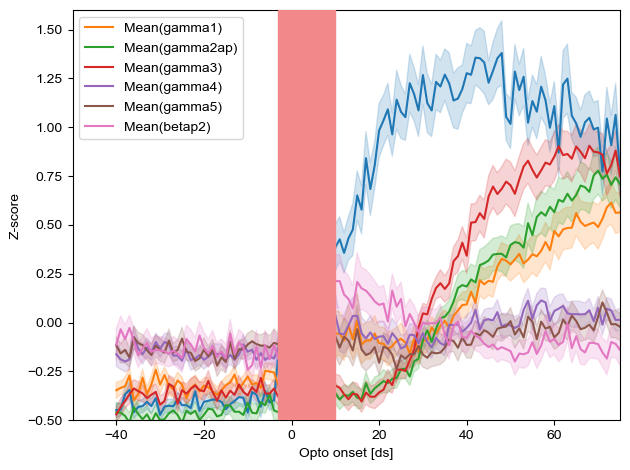

In [12]:
fig, ax = plt.subplots(1,1)
line_legs = sns.lineplot(data=all, x='Opto_onset_time', y='ME_legs', errorbar='se', ax=ax)

for colname in all.columns[2:8]:
    line_calcium = sns.lineplot(data=all, x='Opto_onset_time', y=colname, errorbar='se', ax=ax, label=colname)
    ax.axvline(0, c='k', ls='--')
    ax.set_ylabel('Z-score')
    ax.set_xlabel('Opto onset [ds]')
ax.axvspan(-3, 10, color='#f3888a', alpha=1.0, zorder=10)
ax.set_ylim([-0.5,1.6])
ax.set_xlim([-50,75])
plt.legend()
fig.tight_layout()


# Ext Data Fig 8d

In [13]:
# identify calcium onsets
onset_names = ['gamma1_onset', 'gamma2_onset', 'gamma3_onset', 'gamma4_onset', 'gamma5_onset', 'betap2_onset']
all[onset_names] = 0
for i in all.loc[all.Opto_onset==1].index.tolist():
    for (colname, comp) in zip(onset_names, ['Mean(gamma1)', 'Mean(gamma2ap)','Mean(gamma3)','Mean(gamma4)', 
                                            'Mean(gamma5)','Mean(betap2)']):
        thresh = all[comp].iloc[i-80:i].rolling(5, center=True).mean().mean() +\
            2 * all[comp].iloc[i-80:i].rolling(5, center=True).std().mean()
        above_thresh_idx = np.where(all[comp].iloc[i:i+80].rolling(5, center=True).mean() > thresh)[0] + i
        # print(above_thresh_idx)
        if len(above_thresh_idx)>0:
            all.loc[min(above_thresh_idx), colname] = 1
            # print(min(above_thresh_idx))

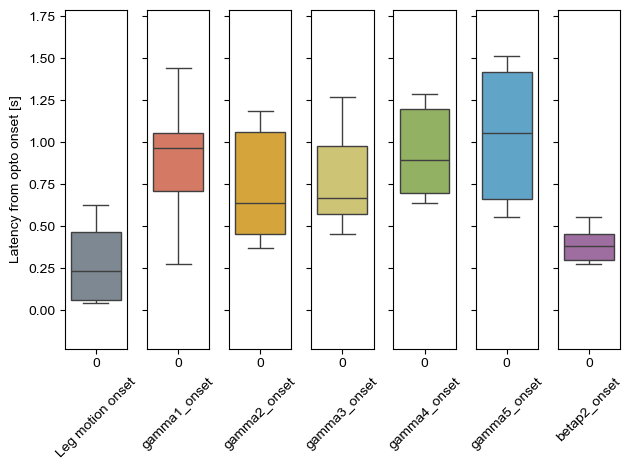

In [14]:
fig, axs = plt.subplots(1,7, sharey=True)
sns.boxplot(all.loc[all.ME_leg_onset==1, ['Recording', 'Opto_onset_time']].groupby('Recording').mean().values/40, 
            ax=axs[0], whis=[10,90], fliersize=0, color=palette['ME_leg'])
# sns.swarmplot(all.loc[all.ME_leg_onset==1, ['Recording', 'Opto_onset_time']].groupby('Recording').mean().values/40, 
#               color='k', ax=axs[0])
axs[0].set_xlabel('Leg motion onset', rotation=45)
axs[0].set_ylabel('Latency from opto onset [s]');

for i, col in zip(range(1,7), onset_names):
    sns.boxplot(all.loc[all[col]==1, ['Recording', 'Opto_onset_time']].groupby('Recording').mean().values/40, 
                ax=axs[i], whis=[10,90], fliersize=0, color=palette[col.split('_')[0]])
    # sns.swarmplot(all.loc[all[col]==1, ['Recording', 'Opto_onset_time']].groupby('Recording').mean().values/40, color='k', ax=axs[i])
    axs[i].set_xlabel(col, rotation=45)
fig.tight_layout()

In [15]:
summary = all.loc[all.ME_leg_onset==1, ['Recording', 'Opto_onset_time']].groupby('Recording').mean().reset_index()
summary['latency'] = 'ME_leg_onset'

for i, col in zip(range(1,7), onset_names):
    exp = all.loc[all[col]==1, ['Recording', 'Opto_onset_time']].groupby('Recording').mean().reset_index()
    exp['latency'] = col
    summary = pd.concat([summary, exp])
summary


,Recording,Opto_onset_time,latency
0,20231208_A67_pre trap+motion,5.750000,ME_leg_onset
1,20231211_A03_pre trap+motion,12.500000,ME_leg_onset
2,20231211_A42 pre+moiton,25.000000,ME_leg_onset
3,20231218_A75_pre+motion,-5.500000,ME_leg_onset
4,20231221_A20_pre+motion,16.600000,ME_leg_onset
...,...,...,...
4,20231227_A46_pre+motion,11.000000,betap2_onset
5,20231229_A24_pre+motion,18.000000,betap2_onset
6,29.06.23_A48_exp,22.200000,betap2_onset
7,29.06.23_A52_exp,12.400000,betap2_onset


In [16]:
summary.Opto_onset_time = summary.Opto_onset_time/40

In [17]:
pg.normality(summary.Opto_onset_time)

,W,pval,normal
Opto_onset_time,0.962971,0.052023,True


In [18]:
pg.rm_anova(data=summary, within='latency', dv='Opto_onset_time', subject='Recording')

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,latency,6,18,3.37422,0.020818,0.316666,0.313423


In [19]:
pg.pairwise_tests(data=summary, within='latency', dv='Opto_onset_time', subject='Recording', padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,latency,ME_leg_onset,betap2_onset,True,True,-4.094778,3.0,two-sided,0.026339,0.500434,holm,3.675,-1.093136
1,latency,ME_leg_onset,gamma1_onset,True,True,-4.368854,3.0,two-sided,0.022180,0.443609,holm,4.126,-1.645893
2,latency,ME_leg_onset,gamma2_onset,True,True,-2.623724,3.0,two-sided,0.078749,1.000000,holm,1.749,-1.847557
3,latency,ME_leg_onset,gamma3_onset,True,True,-4.739118,3.0,two-sided,0.017816,0.374130,holm,4.78,-2.341611
4,latency,ME_leg_onset,gamma4_onset,True,True,-2.855140,3.0,two-sided,0.064835,1.000000,holm,1.996,-1.431547
5,latency,ME_leg_onset,gamma5_onset,True,True,-3.509251,3.0,two-sided,0.039219,0.705941,holm,2.808,-1.383218
6,latency,betap2_onset,gamma1_onset,True,True,-1.470588,3.0,two-sided,0.237764,1.000000,holm,0.834,-0.450647
7,latency,betap2_onset,gamma2_onset,True,True,0.268559,3.0,two-sided,0.805678,1.000000,holm,0.441,0.179853
8,latency,betap2_onset,gamma3_onset,True,True,-0.351574,3.0,two-sided,0.748402,1.000000,holm,0.45,-0.194832
9,latency,betap2_onset,gamma4_onset,True,True,-1.124291,3.0,two-sided,0.342731,1.000000,holm,0.663,-0.462318


# Ext Data Fig 8c

In [20]:
summary_counts = all.loc[all.ME_leg_onset==1, ['Recording', 'Opto_onset_time']].groupby('Recording').count() /\
    all.loc[all.Opto_onset==1, ['Recording', 'Opto_onset_time']].groupby('Recording').count()
summary_counts['var'] = 'ME_leg_onset'

for i, col in zip(range(1,7), onset_names):
    exp = all.loc[all[col]==1, ['Recording', 'Opto_onset_time']].groupby('Recording').count() /\
        all.loc[all.Opto_onset==1, ['Recording', 'Opto_onset_time']].groupby('Recording').count()
    exp['var'] = col
    summary_counts = pd.concat([summary_counts, exp]).fillna(0)
summary_counts


,Opto_onset_time,var
Recording,,
20231208_A67_pre trap+motion,0.800000,ME_leg_onset
20231211_A03_pre trap+motion,1.000000,ME_leg_onset
20231211_A42 pre+moiton,0.833333,ME_leg_onset
20231218_A75_pre+motion,0.666667,ME_leg_onset
20231221_A20_pre+motion,1.000000,ME_leg_onset
...,...,...
20231229_A24_pre+motion,0.200000,betap2_onset
20231229_A74_pre+motion,0.000000,betap2_onset
29.06.23_A48_exp,1.000000,betap2_onset


/var/folders/tt/z91kvz8d6jj096mmy336sdz80000gn/T/ipykernel_94242/2121419393.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


Text(0.5, 1.0, 'Response reliability')

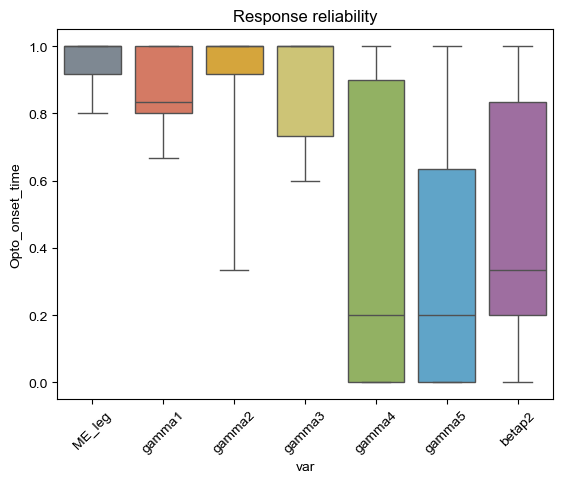

In [21]:
plot_df = summary_counts.reset_index().copy()
plot_df['var'] = plot_df['var'].str.replace('_onset', '', regex=False)

ax = sns.boxplot(
    data=plot_df,
    y='Opto_onset_time',
    x='var',
    whis=[10, 90],
    fliersize=0,
    palette=palette
)

ax.tick_params(axis='x', rotation=45)
ax.set_title('Response reliability')

# sns.swarmplot(summary_counts.reset_index(), y='Opto_onset_time', x='var')
